# Decision Tree Classification in Python

Classification is a two-step process: a learning step and a prediction step. In the learning step, the model is developed based on given training data. In the prediction step, the model is used to predict the response to given data. A decision tree is one of the easiest and most popular classification algorithms used to understand and interpret data. It can be utilized for both classification and regression problems.

---

## The Decision Tree Algorithm

A decision tree is a flowchart-like tree structure where an internal node represents a feature(or attribute), the branch represents a decision rule, and each leaf node represents the outcome.

---

## Decision Tree Classifier Building in Scikit-learn

**Importing required libraries**

Let's first load the required libraries.

---

In [2]:
# Load libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import train_test_split 
from sklearn import metrics 

---
## Loading data

Let's first load the required Pima Indian Diabetes dataset using pandas' read CSV function. You can download the Kaggle data set to follow along.

---

In [3]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
# load dataset
pima = pd.read_csv("diabetes.csv")

In [4]:
pima.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


---

## Feature selection

Here, you need to divide given columns into two types of variables dependent(or target variable) and independent variable(or feature variables).

---

In [5]:
# Sahi column names ka istemal karein
feature_cols = ['Pregnancies', 'Insulin', 'BMI', 'Age', 'Glucose', 'BloodPressure', 'DiabetesPedigreeFunction']

# Ab yeh line error nahi degi
X = pima[feature_cols] 

# Target variable (Outcome)
y = pima.Outcome 

print("X shape:", X.shape)
print("Successfully split!")

X shape: (768, 7)
Successfully split!


---

## Splitting data

Let's split the dataset by using the function train_test_split(). You need to pass three parameters features; target, and test_set size.

---

In [6]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) # 70% training and 30% test


---

## Building a decision tree model

Let's create a decision tree model using Scikit-learn.

---

In [7]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier()

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)


---

## Evaluating the model
Let's estimate how accurately the classifier or model can predict the type of cultivars.

Accuracy can be computed by comparing actual test set values and predicted values.

---


In [8]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))


Accuracy: 0.6666666666666666


---

# Visualizing Decision Trees

You can use Scikit-learn's export_graphviz() function for display the tree within a Jupyter notebook. For plotting the tree, you also need to install graphviz and pydotplus

---

In [9]:
!conda install -y -c anaconda graphviz

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - anaconda
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\B\anaconda3

  added / updated specs:
    - graphviz


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.3.19  |       haa95532_0         165 KB  anaconda
    certifi-2026.4.22          |  py313haa95532_0         136 KB  anaconda
    conda-26.1.1               |  py313haa95532_0         1.4 MB  anaconda
    getopt-win32-0.1           |       h2bbff1b_0          19 KB  anaconda
    glib-2.84.4                |       h60240c0_0         505 KB  anaconda
    glib-tools-2.84.4          |       h3823947_0         124 KB  anaconda
    graphviz-2.50.0            |       hdb8b0d4_0         1.1 MB  anaconda
    gts-0.7.6                  |       h63ab5a1_3         190 KB  anaconda
    libgd-2.3.



==> WARNING: A newer version of conda exists. <==
    current version: 25.11.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c defaults conda




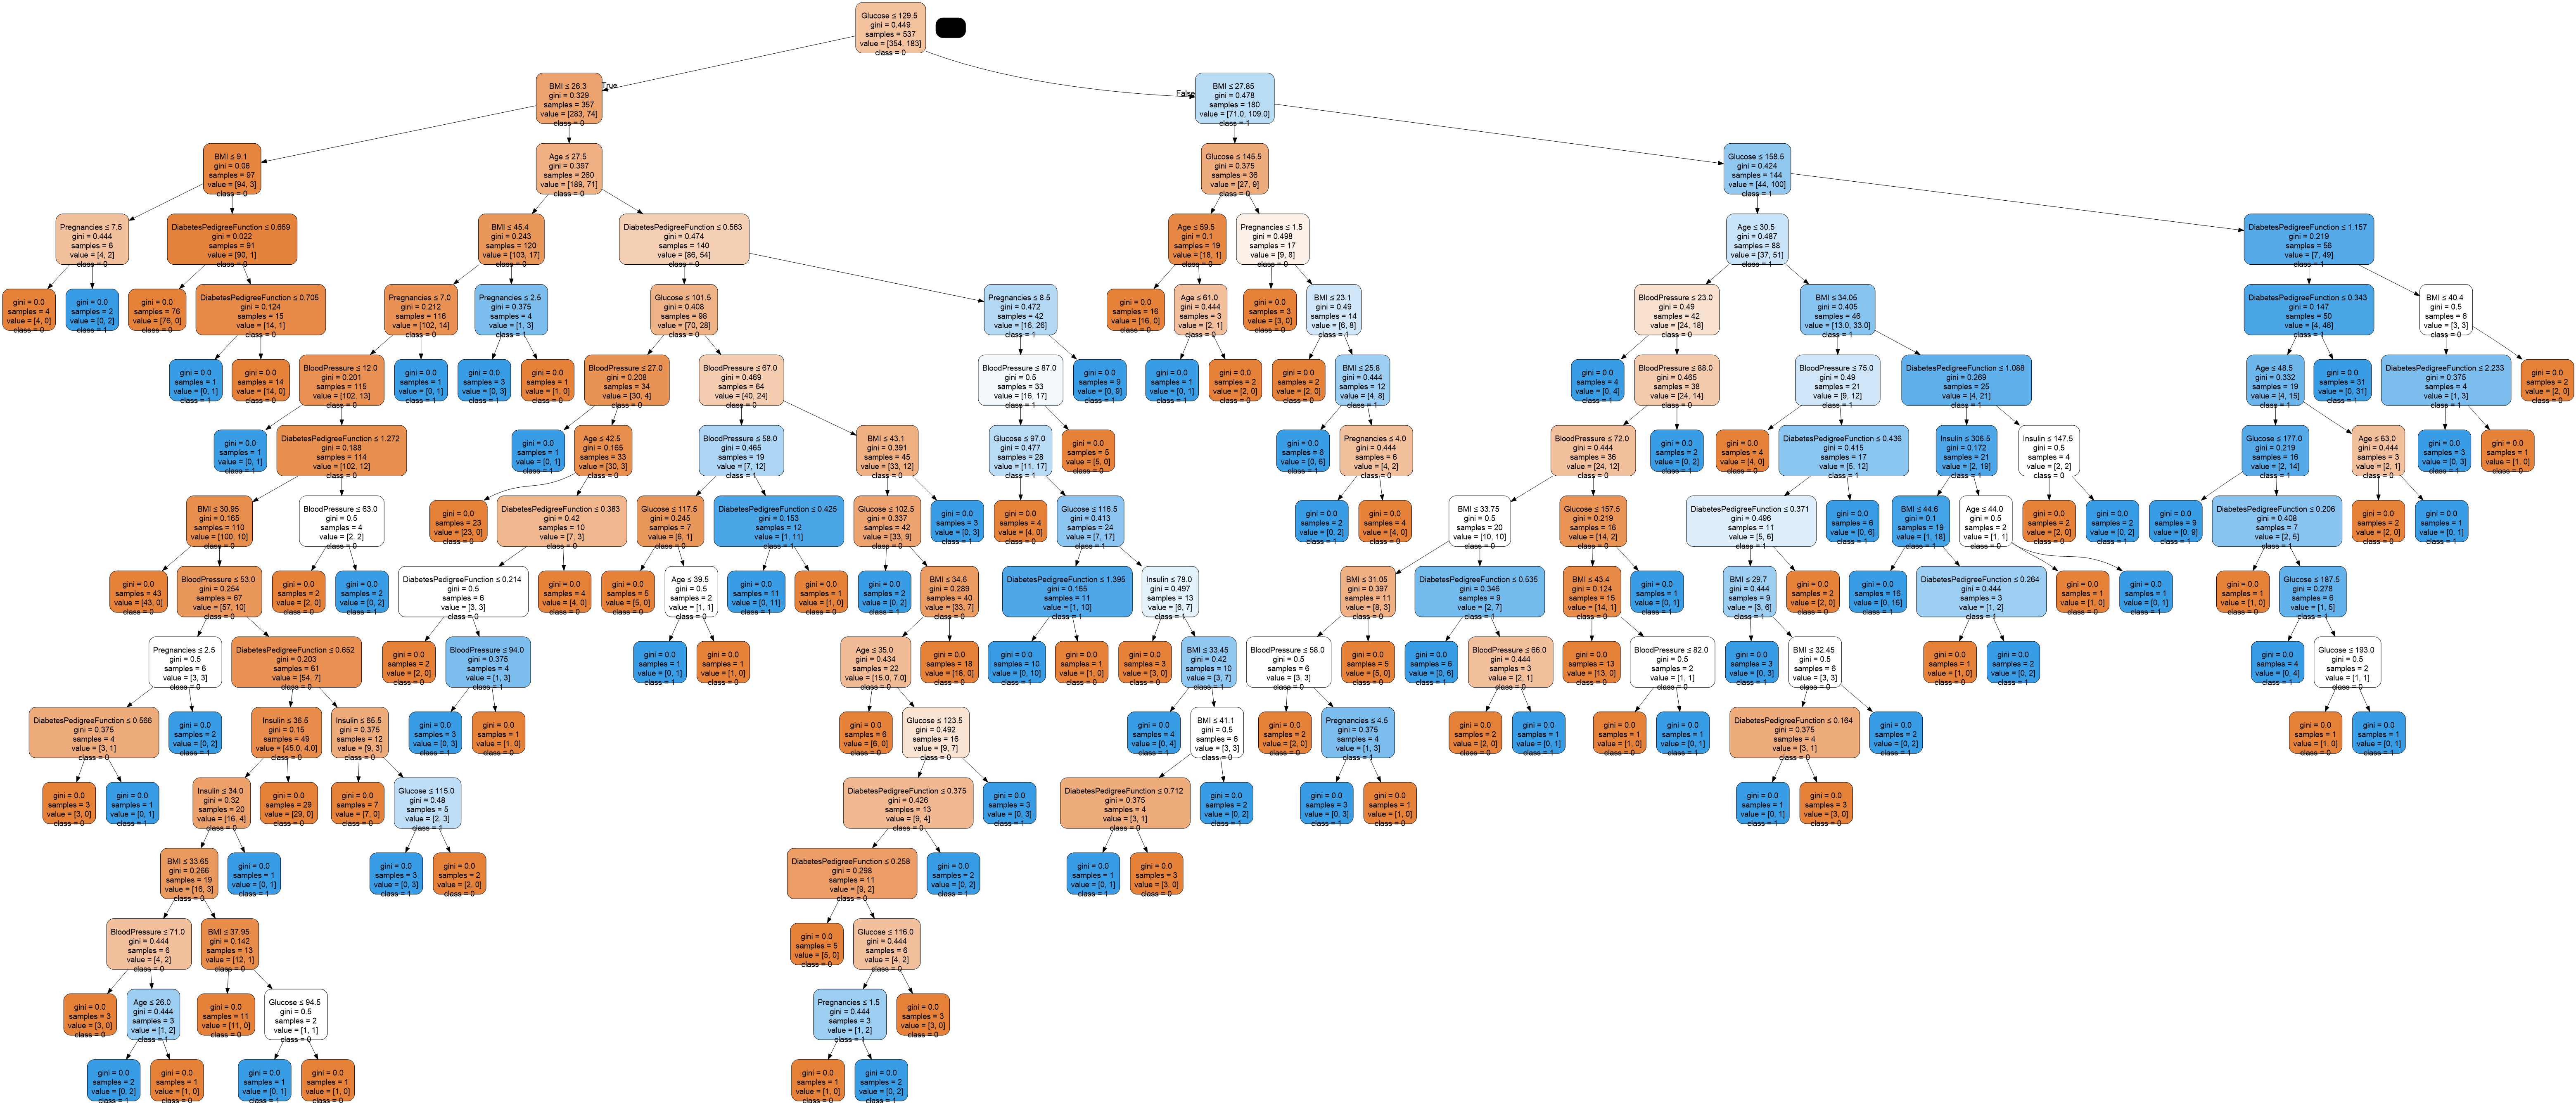

In [10]:
from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus

dot_data = StringIO()
export_graphviz(clf, out_file=dot_data, 
                filled=True, 
                rounded=True, 
                special_characters=True, 
                feature_names=feature_cols,
                class_names=['0','1'])

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('diabetes.png')
Image(graph.create_png())